# Figure S8 — food- and environment-associated SGBs across lifestyles

| Panel | Content |
| --- | --- |
| **S8a left** | Difference in the summed relative abundance of each food signature, non-Westernized vs Westernized |
| **S8a right** | Ratio of the number of food-signature SGBs carried, non-Westernized over Westernized |
| **S8b left** | The same abundance comparison for environment signatures |
| **S8b right** | The same prevalence comparison for environment signatures |

The question behind the figure: non-Westernized gut microbiomes carry SGBs that look like they came
from somewhere else — fermented foods, livestock, other primates, water. Each panel takes a set of
SGBs that mark one source, sums it per sample, and asks whether that sum differs by lifestyle once
study, age, gender, sequencing depth and platform are accounted for.

Two signature sets are built, by the same logic but from different inputs:

* **Food** — profiles from [cFMD](https://github.com/SegataLab/cFMD). An SGB is a signature of a
  food category when its CLR abundance is higher in that category than in all other food samples.
* **Environment** — prevalence tables for rumen, ocean, non-human primate, soil and freshwater
  metagenomes. An SGB is a signature of an environment when it is enriched there by Fisher's test.

Each set is then put through two models of the gut data:

* **Abundance** — a linear mixed model of the summed relative abundance, study as a random effect.
* **Prevalence** — a Poisson GLMM of the *count* of signature SGBs carried. `statsmodels` has no
  Poisson mixed model, so that one is fitted in R with `lme4`; this notebook writes its input table
  and reads its output back (section 7).

## 0. Setup

In [23]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

METADATA = '../data/nw_metadata.tsv'
PROFILES = '../data/nw_profiles.tsv'
CFMD_METADATA = '../data/cFMD_metadata.tsv'

# Written by this notebook, read by the R GLMM step (section 7).
FOOD_MODEL_DATA = '../data/food_modeling_data.tsv'
ENV_MODEL_DATA = '../data/env_modeling_data.tsv'
# Written by the R GLMM step, read back here.
FOOD_GLMM_RESULTS = '../data/food_sig_glmm_results.tsv'
ENV_GLMM_RESULTS = '../data/env_sig_glmm_results.tsv'

MIN_AGE = 16
EXCLUDED_STUDIES = ['HanniganGD_2017']
MIN_FOOD_SAMPLES = 20          # a food category needs more than this many samples
MIN_FOOD_PREVALENCE = 0.1      # an SGB must reach this prevalence inside a food category
MIN_GROUP_SIZE = 10            # smallest group the signature test will run on
SIGNATURE_Q = 0.05             # q-value for an SGB to be a signature of a category
ALPHA = 0.01                   # p-value at which a panel marker turns red

# Categories dropped from the figure: too few signature SGBs overlap the gut data to say anything.
DROPPED_FOOD_CATEGORIES = ['fruits_and_vegetables']
ENVIRONMENTS = ['Rummen', 'Ocean', 'NHP', 'Soil', 'Freshwater']
DROPPED_ENVIRONMENTS = ['soil']
ENVIRONMENT_NAMES = {'NHP': 'non-human primates', 'Rummen': 'rumen', 'Ocean': 'ocean',
                     'Soil': 'soil', 'Freshwater': 'freshwater'}

ENV_MIN_PREVALENCE = 0.10      # prevalence inside the environment
ENV_MIN_RATIO = 2              # prevalence there over prevalence elsewhere
ENV_Q = 0.05

SIGNIFICANT_COLOR = 'red'
NONSIGNIFICANT_COLOR = 'lightskyblue'
NULL_COLOR = 'red'

COVARIATES = ['study_name', 'age', 'gender', 'sequencing_platform',
              'DNA_extraction_kit', 'number_reads']
META_COLS = ['non_westernized'] + COVARIATES
MODEL_FORMULA = 'non_westernized + age + gender + number_reads + sequencing_platform'

sns.set_theme(context='paper', style='whitegrid', font='DejaVu Sans')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.labelweight': 'bold', 'legend.frameon': False,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

## 1. Gut metadata and abundances

Adults over 16 with a usable age, plus the ancient samples, which are carried through the tables and
dropped at the modelling step. One malformed age value and `HanniganGD_2017` are excluded.

In [2]:
metadata = pd.read_table(METADATA)

adults = metadata[metadata['age'].notna() & (metadata['age'] != '1.083.333.333')].copy()
adults['age'] = adults['age'].astype(float)
adults = adults[(adults['age'] > MIN_AGE) & (~adults['study_name'].isin(EXCLUDED_STUDIES))]
adults = adults.set_index('sample_id', drop=False)

ancient = metadata[metadata['non_westernized'] == 'ancient'].set_index('sample_id', drop=False)
sample_metadata = pd.concat([ancient, adults])

print(f'{len(adults):,} adults, {len(ancient):,} ancient samples')

6,863 adults, 29 ancient samples


SGB identifiers are rewritten as `SGBxxxx__Species_name`, the form used by the environment
prevalence table and by the modelling tables, so that every SGB set can be intersected directly.

In [3]:
SGB_LABEL = re.compile(r'(.+?) \((.+)\)')

def sgb_key(label):
    """'Prevotella copri (SGB1626)' -> 'SGB1626__Prevotella_copri'."""
    species, sgb_id = SGB_LABEL.match(label).groups()
    return f'{sgb_id}__{species}'.replace(' ', '_')


def read_sgb_profiles(path):
    """Read a merged MetaPhlAn table and keep the SGB rows, labelled 'Species (SGBid)'."""
    table = pd.read_table(path, index_col=0)
    table = table.loc[['t__' in clade for clade in table.index]]
    table.index = [clade.split('|')[-2][3:].replace('_', ' ') + ' (' + clade.split('|')[-1][3:] + ')'
                   for clade in table.index]
    return table


sgb_abundances = read_sgb_profiles(PROFILES)

abundances = sgb_abundances[[s for s in sample_metadata.index if s in sgb_abundances.columns]]
abundances = abundances.loc[abundances.sum(axis=1) > 0].T        # samples x SGBs
abundances = abundances.loc[abundances.sum(axis=1) > 0]
abundances.columns = [sgb_key(label) for label in abundances.columns]

print(f'{abundances.shape[0]:,} samples x {abundances.shape[1]:,} SGBs')

6,888 samples x 4,438 SGBs


One table joins the covariates to the abundances. Ancient samples have no lifestyle to compare, so
they leave here; `DNA_extraction_kit` and `gender` keep an explicit `unknown` level rather than
dropping those samples.

In [4]:
meta_analysis = sample_metadata[META_COLS].merge(abundances, left_index=True, right_index=True)
meta_analysis = meta_analysis[meta_analysis['non_westernized'].isin(['yes', 'no'])]
meta_analysis['DNA_extraction_kit'] = meta_analysis['DNA_extraction_kit'].fillna('unknown')
meta_analysis['gender'] = meta_analysis['gender'].fillna('unknown')

SGB_COLS = [c for c in meta_analysis.columns if c not in META_COLS]

print(f'{len(meta_analysis):,} samples, {len(SGB_COLS):,} SGBs')
meta_analysis['non_westernized'].value_counts()

6,861 samples, 4,438 SGBs


no     5661
yes    1200
Name: non_westernized, dtype: int64

## 2. Food signatures

### 2.1 cFMD samples with matching profiles

Only the cFMD datasets that have Jan21 MetaPhlAn4 profiles on disk can be used, and only the food
categories with more than 20 samples are kept, since the signature test compares one category
against all the others.

In [6]:
def jan21_profile_dir(dataset):
    """The Jan21 MetaPhlAn4 results directory of one dataset, or None if it has none."""
    root = os.path.join(DATA_DIR, dataset)
    if not os.path.isdir(root):
        return None
    matches = [d for d in os.listdir(root) if 'metaphlan-4' in d and 'Jan21' in d]
    return matches[0] if matches else None


food_meta = pd.read_table(CFMD_METADATA)

profile_dirs = {dataset: jan21_profile_dir(dataset)
                for dataset in food_meta['dataset_name'].unique()}
available = {dataset for dataset, directory in profile_dirs.items() if directory}
print(f'datasets with Jan21 profiles: {len(available)}/{len(profile_dirs)}')

food_meta = food_meta[food_meta['dataset_name'].isin(available)].copy()
food_meta['profile_path'] = [
    os.path.join(DATA_DIR, row['dataset_name'], profile_dirs[row['dataset_name']],
                 row['sample_id'], f"{row['sample_id']}_profile.tsv")
    for _, row in food_meta.iterrows()]

category_sizes = food_meta['category'].value_counts()
food_meta = food_meta[food_meta['category'].isin(category_sizes[category_sizes > MIN_FOOD_SAMPLES].index)]
food_meta = food_meta.set_index(food_meta['dataset_name'] + '_' + food_meta['sample_id'])
food_meta.index.name = 'unique_sample_id'

food_meta['category'].value_counts()

datasets with Jan21 profiles: 59/85


dairy                              1650
fermented_beverages                 422
fermented_meat                      133
fermented_grains                     80
alcohol                              48
meat                                 47
fermented_fruits_and_vegetables      34
fruits_and_vegetables                25
fermented_tubers_and_roots           24
Name: category, dtype: int64

### 2.2 Food abundance table

One MetaPhlAn profile per food sample. An SGB is kept only where it reaches 10% prevalence inside
the food category it is being tested for, which drops the long tail of one-off detections that would
otherwise dominate the multiple-testing correction.

In [24]:
food_wide = pd.read_table("cFMD_abundances.tsv.bz2", compression="bz2", index_col=0)
food_wide.to_csv("../data/cFMD_abundances.tsv.bz2", compression="bz2", sep="\t")


In [14]:
food_wide = pd.read_table("../data/cFMD_abundances.tsv.bz2", compression="bz2", index_col=0)

food_categories = food_meta.loc[food_wide.index, 'category']
print(f'{food_wide.shape[0]:,} food samples x {food_wide.shape[1]:,} SGBs')

# Prevalence of each SGB inside each food category, used as a per-category filter.
prevalence = (food_wide > 0).astype(int).groupby(food_categories).mean()
keep_anywhere = (prevalence > MIN_FOOD_PREVALENCE).any()
food_wide = food_wide.loc[:, keep_anywhere]

print(f'{food_wide.shape[1]:,} SGBs above {MIN_FOOD_PREVALENCE:.0%} prevalence in some category')

2,430 food samples x 3,165 SGBs
655 SGBs above 10% prevalence in some category


In [15]:
food_wide.head()

,Acetobacter cerevisiae (SGB1200),Acetobacter cibinongensis (SGB1188),Acetobacter fabarum (SGB1190),Acetobacter ghanensis (SGB1192),Acetobacter indonesiensis (SGB1203),Acetobacter lambici (SGB89217),Acetobacter lovaniensis (SGB89218),Acetobacter malorum (SGB1201),Acetobacter okinawensis (SGB1191),Acetobacter orientalis (SGB1187),...,Weissella hellenica (SGB29577),Weissella paramesenteroides (SGB7118),Weissella soli (SGB24990),Williamsia phyllosphaerae (SGB86971),Xanthomonas arboricola (SGB12431),Xanthomonas campestris (SGB12430),Xanthomonas citri (SGB12423_group),Yonghaparkia alkaliphila (SGB87797),Zymobacter palmae (SGB32412),Zymomonas mobilis (SGB19526)
AlvarezOrdonezA_xxxx_C01-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AlvarezOrdonezA_xxxx_C01-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AlvarezOrdonezA_xxxx_C02-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AlvarezOrdonezA_xxxx_C02-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AlvarezOrdonezA_xxxx_C02-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.3 Signature SGBs per food category

Abundances are CLR transformed, so each sample's values are log ratios to its own geometric mean
rather than raw proportions, and then each SGB is tested one-sidedly against all other food samples.
The q-values are corrected over every SGB-category pair at once.

In [16]:
def clr_transform(frame, pseudocount=1e-6):
    """Centred log-ratio transform of a samples x features abundance table."""
    log_abundance = np.log(frame + pseudocount)
    return log_abundance.sub(log_abundance.mean(axis=1), axis=0)


clr_food = clr_transform(food_wide)

rows = []
for category in food_categories.unique():
    in_category = food_categories == category
    if in_category.sum() < MIN_GROUP_SIZE or (~in_category).sum() < MIN_GROUP_SIZE:
        continue
    for sgb in clr_food.columns:
        inside, outside = clr_food.loc[in_category, sgb], clr_food.loc[~in_category, sgb]
        rows.append({
            'sgb_id': sgb,
            'food_category': category,
            'pval': mannwhitneyu(inside, outside, alternative='greater').pvalue,
            'mean_diff': inside.mean() - outside.mean(),
        })

food_signatures = pd.DataFrame(rows)
food_signatures['qval'] = multipletests(food_signatures['pval'], method='fdr_bh')[1]

food_sig_sets = (food_signatures[food_signatures['qval'] < SIGNATURE_Q]
                 .assign(sgb_id=lambda f: f['sgb_id'].map(sgb_key))
                 .groupby('food_category')['sgb_id'].apply(list).to_dict())

pd.Series({category: len(sgbs) for category, sgbs in food_sig_sets.items()},
          name='signature SGBs').sort_values(ascending=False).to_frame()

,signature SGBs
dairy,626
fermented_grains,557
alcohol,36
fermented_beverages,32
meat,19
fermented_meat,18
fruits_and_vegetables,13
fermented_fruits_and_vegetables,11
fermented_tubers_and_roots,4


## 3. Environment signatures

The environment input is already a prevalence table: how many samples of each environment carry each
SGB. An SGB is a signature of an environment when Fisher's test calls it enriched there against all
the other environments pooled, it reaches 10% prevalence there, and that prevalence is at least
double its prevalence elsewhere. The last two conditions are what stop ubiquitous SGBs qualifying on
sample size alone.

In [17]:
env_prevalence = pd.read_table(ENV_PREVALENCES,
                               names=['environment', 'sgb_id', 'n_present_samples',
                                      'n_total_samples'])
env_prevalence = env_prevalence[env_prevalence['environment'].isin(ENVIRONMENTS)]

samples_per_env = env_prevalence.groupby('environment')['n_total_samples'].first()
total_samples = samples_per_env.sum()
present_per_sgb = env_prevalence.groupby('sgb_id')['n_present_samples'].sum()

rows = []
for environment, env_rows in env_prevalence.groupby('environment'):
    n_other = total_samples - samples_per_env[environment]
    for _, row in env_rows.iterrows():
        present_here = row['n_present_samples']
        absent_here = row['n_total_samples'] - present_here
        present_elsewhere = present_per_sgb[row['sgb_id']] - present_here
        absent_elsewhere = n_other - present_elsewhere
        odds_ratio, pval = fisher_exact([[present_here, present_elsewhere],
                                         [absent_here, absent_elsewhere]], alternative='greater')
        rows.append({
            'environment': environment, 'sgb_id': row['sgb_id'],
            'odds_ratio': odds_ratio, 'pval': pval,
            'prevalence_env': present_here / (present_here + absent_here),
            'prevalence_other': present_elsewhere / (present_elsewhere + absent_elsewhere),
        })

env_results = pd.DataFrame(rows)
env_results['qval'] = multipletests(env_results['pval'], method='fdr_bh')[1]

env_signatures = env_results[
    (env_results['qval'] < ENV_Q)
    & (env_results['prevalence_env'] >= ENV_MIN_PREVALENCE)
    & (env_results['prevalence_env'] / (env_results['prevalence_other'] + 1e-9) >= ENV_MIN_RATIO)]

env_sig_sets = env_signatures.groupby('environment')['sgb_id'].apply(list).to_dict()

pd.Series({environment: len(sgbs) for environment, sgbs in env_sig_sets.items()},
          name='signature SGBs').sort_values(ascending=False).to_frame()

,signature SGBs
Rummen,1308
Ocean,994
NHP,578
Freshwater,74
Soil,66


## 4. Summing the signatures per gut sample

Both models take the same shape of input: one column per signature set, holding either the summed
relative abundance of the set's SGBs in that sample, or the count of them present. Only the SGBs
that exist in the gut data count, so how much of a signature survives the intersection matters as
much as the model — the table below reports it.

In [18]:
def signature_table(sgb_sets, binary):
    """Covariates plus one column per signature set: summed abundance, or number present."""
    values = (meta_analysis[SGB_COLS] > 0).astype(int) if binary else meta_analysis[SGB_COLS] / 100
    table = meta_analysis[META_COLS].copy()
    for name, sgbs in sgb_sets.items():
        present = [sgb for sgb in sgbs if sgb in values.columns]
        table['sig_' + name] = values[present].sum(axis=1)
    return table


def prepare_for_model(table, dropped):
    """Drop the unusable rows and columns, and type the variables the formula expects."""
    table = table[table['gender'].isin(['male', 'female'])].copy()
    table = table.drop(columns=['sig_' + name for name in dropped if 'sig_' + name in table])
    table['non_westernized'] = table['non_westernized'].map({'yes': 1, 'no': 0})
    table['age'] = table['age'].astype(float)
    table['number_reads'] = table['number_reads'].astype(float)
    for column in ('gender', 'sequencing_platform'):
        table[column] = table[column].astype('category')
    return table


overlap = pd.DataFrame([
    {'set': name, 'signature SGBs': len(sgbs),
     'in gut data': sum(sgb in SGB_COLS for sgb in sgbs)}
    for name, sgbs in {**food_sig_sets, **env_sig_sets}.items()]).set_index('set')
overlap['% kept'] = (100 * overlap['in gut data'] / overlap['signature SGBs']).round(1)
overlap.sort_values('in gut data', ascending=False)

,signature SGBs,in gut data,% kept
set,,,
NHP,578,545,94.3
dairy,626,282,45.0
fermented_grains,557,223,40.0
Rummen,1308,199,15.2
alcohol,36,20,55.6
fermented_meat,18,17,94.4
meat,19,16,84.2
fermented_beverages,32,15,46.9
Ocean,994,13,1.3


## 5. Abundance models

A linear mixed model per signature set: the summed relative abundance against lifestyle, with age,
gender, sequencing depth and platform as fixed effects and study as a random intercept. The
coefficient on `non_westernized` is the difference in summed relative abundance between the two
lifestyles, which is what the left-hand panels plot. The error bars are one standard error, as in
the published figure, not a 95% interval.

In [19]:
def lifestyle_effects(table, category_col):
    """Mixed-model lifestyle coefficient for every signature column of a table."""
    rows = []
    for column in [c for c in table.columns if c.startswith('sig_')]:
        fitted = smf.mixedlm(f'{column} ~ {MODEL_FORMULA}', table,
                             groups=table['study_name']).fit()
        rows.append({
            category_col: column[4:],
            'coef': fitted.params['non_westernized'],
            'stderr': fitted.bse['non_westernized'],
            'pval': fitted.pvalues['non_westernized'],
        })
    results = pd.DataFrame(rows)
    results['ci_lower'] = results['coef'] - results['stderr']
    results['ci_upper'] = results['coef'] + results['stderr']
    return results


food_abundance = lifestyle_effects(
    prepare_for_model(signature_table(food_sig_sets, binary=False), DROPPED_FOOD_CATEGORIES),
    'food_category')
food_abundance['food_category'] = food_abundance['food_category'].str.replace('_', ' ')

env_abundance = lifestyle_effects(
    prepare_for_model(signature_table(env_sig_sets, binary=False), []), 'environment')
env_abundance['environment'] = env_abundance['environment'].map(ENVIRONMENT_NAMES)
env_abundance = env_abundance[~env_abundance['environment'].isin(DROPPED_ENVIRONMENTS)]

pd.concat([food_abundance.rename(columns={'food_category': 'set'}),
           env_abundance.rename(columns={'environment': 'set'})]).sort_values('coef')

/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: 

,set,coef,stderr,pval,ci_lower,ci_upper
4,fermented grains,-0.025668,0.004854,1.238734e-07,-0.030522,-0.020814
1,dairy,-0.018646,0.007159,9.200416e-03,-0.025805,-0.011487
3,fermented fruits and vegetables,-0.003680,0.003244,2.565928e-01,-0.006924,-0.000436
7,meat,-0.000067,0.000199,7.343322e-01,-0.000266,0.000131
5,fermented meat,0.000013,0.000086,8.780160e-01,-0.000073,0.000099
2,fermented beverages,0.000048,0.000052,3.571151e-01,-0.000004,0.000101
0,alcohol,0.000351,0.000169,3.721084e-02,0.000183,0.000520
6,fermented tubers and roots,0.000374,0.000159,1.824413e-02,0.000216,0.000533
0,freshwater,0.009686,0.004076,1.748292e-02,0.005610,0.013762
2,ocean,0.009706,0.004078,1.729232e-02,0.005629,0.013784


## 6. Prevalence model input

The same tables, counting signature SGBs instead of summing their abundance. These are counts with a
study-level random effect, which `statsmodels` cannot fit — hence the handover to R below. Both
tables are written out here.

In [20]:
food_prevalence_data = prepare_for_model(signature_table(food_sig_sets, binary=True),
                                         DROPPED_FOOD_CATEGORIES)
env_prevalence_data = prepare_for_model(signature_table(env_sig_sets, binary=True), [])

food_prevalence_data.to_csv(FOOD_MODEL_DATA, sep='\t')
env_prevalence_data.to_csv(ENV_MODEL_DATA, sep='\t')

print(f'{FOOD_MODEL_DATA}: {food_prevalence_data.shape}')
print(f'{ENV_MODEL_DATA}: {env_prevalence_data.shape}')
food_prevalence_data.filter(like='sig_').describe().T[['mean', 'max']]

../data/food_modeling_data.tsv: (6824, 15)
../data/env_modeling_data.tsv: (6824, 12)


,mean,max
sig_alcohol,0.259379,7.0
sig_dairy,5.645662,33.0
sig_fermented_beverages,0.101846,5.0
sig_fermented_fruits_and_vegetables,0.958675,6.0
sig_fermented_grains,3.187573,27.0
sig_fermented_meat,0.148154,5.0
sig_fermented_tubers_and_roots,0.203839,4.0
sig_meat,0.019343,8.0


## 7. Prevalence models in R

The Poisson GLMM is fitted outside the notebook, once per signature column, and the results are
written to the two TSVs read below. Run the following script in R to get the results of the GLMM:

```r
library(lme4)
library(broom.mixed)

data <- read.delim("../data/food_modeling_data.tsv", row.names = 1)
signatures <- grep("^sig_", names(data), value = TRUE)

results <- do.call(rbind, lapply(signatures, function(sig) {
  formula <- as.formula(paste(sig,
    "~ non_westernized + age + gender + number_reads + sequencing_platform + (1 | study_name)"))
  fit <- glmer(formula, data = data, family = poisson)
  out <- as.data.frame(coef(summary(fit)))
  out$parameter <- rownames(out)
  ci <- confint(fit, method = "Wald", parm = "beta_")
  out$ci_lower <- ci[out$parameter, 1]
  out$ci_upper <- ci[out$parameter, 2]
  out$food_category <- sig
  out
}))

write.table(results, "../data/food_sig_glmm_results.tsv", sep = "\t", row.names = FALSE)
```

Check this against the real script before trusting the numbers. The same thing is run on
`env_modeling_data.tsv` with the output column still named `food_category`, which is why the reader
below renames it rather than expecting `environment`.

A Poisson coefficient is a log rate ratio, so exponentiating it gives the factor by which the number
of signature SGBs carried changes — the "prevalence ratio (NW/W)" of the right-hand panels. The null
is therefore 1, not 0.

In [21]:
def read_glmm_results(path, category_col, names=None, dropped=()):
    """Read the R GLMM output and put the lifestyle term on the rate-ratio scale."""
    results = pd.read_table(path)
    results = results[results['parameter'] == 'non_westernizedyes'].copy()
    results = results.rename(columns={'Pr(>|z|)': 'pval', 'food_category': category_col})

    for column, source in (('coef', 'Estimate'), ('ci_lower', 'ci_lower'), ('ci_upper', 'ci_upper')):
        results[column] = np.exp(results[source])

    labels = results[category_col].str.replace('^sig_', '', regex=True)
    results[category_col] = labels.map(names) if names else labels.str.replace('_', ' ')
    return results[~results[category_col].isin(dropped)]


food_prevalence = read_glmm_results(FOOD_GLMM_RESULTS, 'food_category',
                                    dropped=[c.replace('_', ' ') for c in DROPPED_FOOD_CATEGORIES])
env_prevalence = read_glmm_results(ENV_GLMM_RESULTS, 'environment',
                                   names=ENVIRONMENT_NAMES, dropped=DROPPED_ENVIRONMENTS)

pd.concat([food_prevalence.rename(columns={'food_category': 'set'}),
           env_prevalence.rename(columns={'environment': 'set'})])[
    ['set', 'coef', 'ci_lower', 'ci_upper', 'pval']].sort_values('coef', ascending=False)

/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/miniconda3/envs/wnw/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


,set,coef,ci_lower,ci_upper,pval
43,fermented tubers and roots,5.811071,3.744346,9.018545,4.242488e-15
1,alcohol,3.614840,2.443193,5.348358,1.280476e-10
8,non-human primates,3.349975,3.215710,3.489846,0.000000e+00
22,rumen,2.221968,2.002216,2.465838,4.913814e-51
15,ocean,1.443686,1.228768,1.696195,8.004967e-06
1,freshwater,1.218063,1.045785,1.418722,1.123210e-02
29,fermented grains,1.012797,0.854013,1.201102,8.838032e-01
8,dairy,0.878283,0.743862,1.036994,1.256764e-01
15,fermented beverages,0.626940,0.314156,1.251139,1.853573e-01
22,fermented fruits and vegetables,0.559011,0.424593,0.735984,3.405144e-05


## 8. Figure S8

Four panels of the same kind: one row per signature set, the effect as a dot with its interval, red
where the lifestyle term reaches p < 0.01. The dashed line is the null — zero difference for the
abundance panels, a ratio of one for the prevalence panels. Each panel is sorted by its own effect,
so a category can sit at a different height on the left and the right.

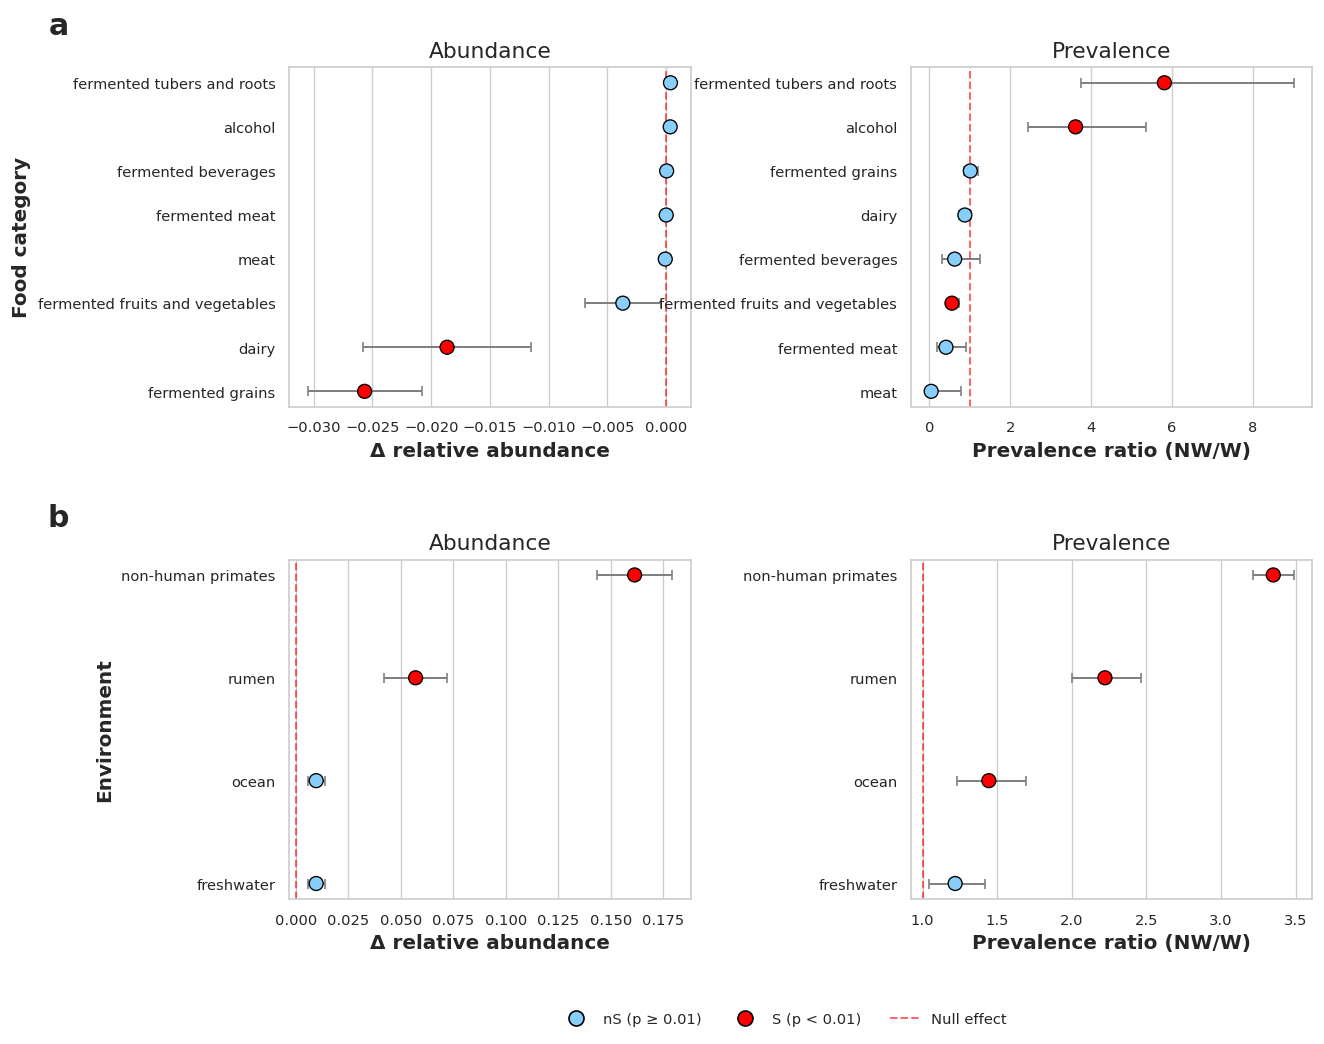

In [22]:
def plot_coefficients(ax, results, category_col, xlabel, baseline=0.0, title=None):
    """One forest-style panel: effect, interval, and significance colouring."""
    data = results.sort_values('coef')
    y = np.arange(len(data))
    colors = np.where(data['pval'] < ALPHA, SIGNIFICANT_COLOR, NONSIGNIFICANT_COLOR)

    ax.errorbar(x=data['coef'], y=y,
                xerr=[data['coef'] - data['ci_lower'], data['ci_upper'] - data['coef']],
                fmt='none', ecolor='gray', elinewidth=1.2, capsize=3, zorder=1)
    ax.scatter(data['coef'], y, c=colors, s=70, edgecolor='black', linewidths=0.8, zorder=3)
    ax.axvline(baseline, color=NULL_COLOR, linestyle='--', alpha=0.6, linewidth=1.2, zorder=2)

    ax.set_yticks(y)
    ax.set_yticklabels(data[category_col])
    ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title)
    ax.grid(axis='y', visible=False)
    return ax


PANELS = [
    ('a', 'Food category', food_abundance, food_prevalence, 'food_category'),
    ('b', 'Environment', env_abundance, env_prevalence, 'environment'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.55})

for row, (letter, ylabel, abundance, prevalence, category_col) in enumerate(PANELS):
    plot_coefficients(axes[row, 0], abundance, category_col,
                      xlabel='\u0394 relative abundance', baseline=0.0, title='Abundance')
    plot_coefficients(axes[row, 1], prevalence, category_col,
                      xlabel='Prevalence ratio (NW/W)', baseline=1.0, title='Prevalence')
    axes[row, 0].set_ylabel(ylabel)
    axes[row, 0].text(-0.55, 1.08, letter, transform=axes[row, 0].transAxes,
                      fontsize=18, fontweight='bold', va='bottom', ha='right')

fig.legend(handles=[
    Line2D([], [], marker='o', linestyle='', markersize=9, markeredgecolor='black',
           markerfacecolor=NONSIGNIFICANT_COLOR, label=f'nS (p \u2265 {ALPHA})'),
    Line2D([], [], marker='o', linestyle='', markersize=9, markeredgecolor='black',
           markerfacecolor=SIGNIFICANT_COLOR, label=f'S (p < {ALPHA})'),
    Line2D([], [], linestyle='--', color=NULL_COLOR, alpha=0.6, label='Null effect'),
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
plt.show()